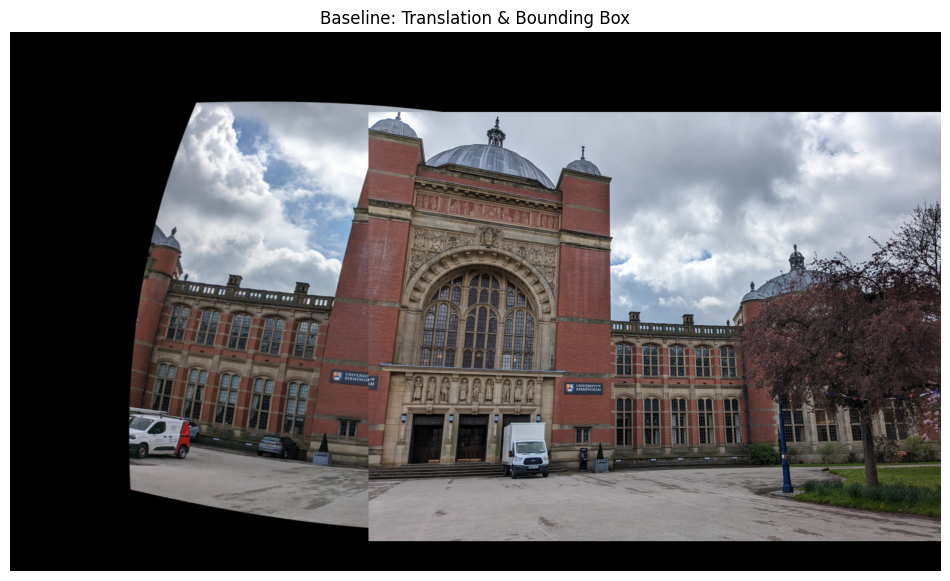

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取图像
img1 = cv2.imread('UOB1.jpg') 
img2 = cv2.imread('UOB2.jpg')

if img1 is None or img2 is None:
    raise ValueError("The image cannot be found. Please check the path!")

# 2. 缩小图像 (30%) 防止内存溢出
scale_percent = 30 
width1 = int(img1.shape[1] * scale_percent / 100)
height1 = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width1, height1), interpolation=cv2.INTER_AREA)

width2 = int(img2.shape[1] * scale_percent / 100)
height2 = int(img2.shape[0] * scale_percent / 100)
img2 = cv2.resize(img2, (width2, height2), interpolation=cv2.INTER_AREA)

# 转换颜色空间
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 3. SIFT 特征提取 (限制最多 2000 个特征点)
sift = cv2.SIFT_create(nfeatures=2000) 
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# 4. 特征匹配 (KNN + Lowe's Ratio Test)
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# 5. 计算单应性矩阵 H 与平移矩阵 T 进行拼接
if len(good_matches) > 4:
    # 提取匹配点的坐标
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

    # 【这就是刚才丢失的 H 矩阵计算！】
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # 获取图像尺寸
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # 获取 UOB1 和 UOB2 的四个角
    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    # 预测 UOB1 的角会被 H 矩阵扭曲到哪里
    warped_corners_img1 = cv2.perspectiveTransform(corners_img1, H)

    # 找出 Bounding Box (最小和最大坐标)
    all_corners = np.concatenate((warped_corners_img1, corners_img2), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # 计算平移距离
    t_x = -x_min if x_min < 0 else 0
    t_y = -y_min if y_min < 0 else 0

    # 构建平移矩阵 T
    T = np.array([[1, 0, t_x],
                  [0, 1, t_y],
                  [0, 0, 1]], dtype=np.float32)

    # 计算新画布的尺寸
    canvas_width = x_max - x_min
    canvas_height = y_max - y_min

    # T 和 H 结合：先扭曲再平移
    H_translation = T.dot(H)
    
    # 扭曲 UOB1
    result = cv2.warpPerspective(img1_rgb, H_translation, (canvas_width, canvas_height))

    # 平移 UOB2
    result_img2 = cv2.warpPerspective(img2_rgb, T, (canvas_width, canvas_height))
    
    # 图像融合 (简单覆盖)
    gray_result_img2 = cv2.cvtColor(result_img2, cv2.COLOR_RGB2GRAY)
    mask = (gray_result_img2 > 0)
    result[mask] = result_img2[mask]

    # 可视化结果
    plt.figure(figsize=(15, 7))
    plt.imshow(result)
    plt.title("Baseline: Translation & Bounding Box")
    plt.axis('off') 
    plt.show()

else:
    print("No sufficient matching points were found to calculate the homography matrix.")

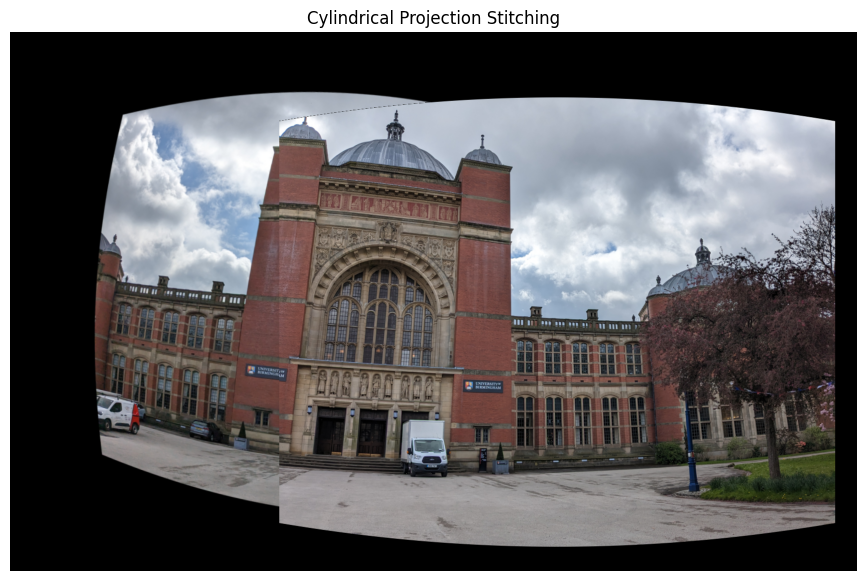

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定义柱面投影核心函数 ---
def cylindrical_projection(img, focal_length):
    """
    将平面图像投影到柱面坐标系上
    """
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    
    # 创建图像的坐标网格
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    # 计算柱面坐标系下的角度和高度
    theta = (x - cx) / focal_length
    h_cyl = (y - cy) / focal_length
    
    # 逆向映射：计算平面坐标系中对应的像素位置
    X_flat = focal_length * np.tan(theta) + cx
    Y_flat = focal_length * h_cyl / np.cos(theta) + cy
    
    # 转换为 float32 格式供 cv2.remap 使用
    map_x = X_flat.astype(np.float32)
    map_y = Y_flat.astype(np.float32)
    
    # 执行重映射 (超出边界的像素填成黑色)
    warped_img = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    return warped_img


# --- 2. 读取与预处理 ---
img1 = cv2.imread('UOB1.jpg') 
img2 = cv2.imread('UOB2.jpg')

if img1 is None or img2 is None:
    raise ValueError("找不到图片，请检查路径！")

# 缩小图像 (30%)
scale_percent = 30 
width1 = int(img1.shape[1] * scale_percent / 100)
height1 = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width1, height1), interpolation=cv2.INTER_AREA)

width2 = int(img2.shape[1] * scale_percent / 100)
height2 = int(img2.shape[0] * scale_percent / 100)
img2 = cv2.resize(img2, (width2, height2), interpolation=cv2.INTER_AREA)

# 【核心新增：执行柱面投影！】
# 估算焦距：这里我们假设焦距等于图像宽度，你可以在报告里讨论如果改变这个值会发生什么
focal_length_estimate = width1 
cyl_img1 = cylindrical_projection(img1, focal_length_estimate)
cyl_img2 = cylindrical_projection(img2, focal_length_estimate)

# 转换颜色空间 (注意：后续所有操作都基于投影后的 cyl_img)
img1_rgb = cv2.cvtColor(cyl_img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(cyl_img2, cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(cyl_img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(cyl_img2, cv2.COLOR_BGR2GRAY)


# --- 3. 提取特征、匹配、计算变换矩阵 ---
sift = cv2.SIFT_create(nfeatures=2000) 
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

if len(good_matches) > 4:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # --- 4. 计算边界框并平移拼接 ---
    h1, w1 = cyl_img1.shape[:2]
    h2, w2 = cyl_img2.shape[:2]

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    warped_corners_img1 = cv2.perspectiveTransform(corners_img1, H)

    all_corners = np.concatenate((warped_corners_img1, corners_img2), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    t_x = -x_min if x_min < 0 else 0
    t_y = -y_min if y_min < 0 else 0

    T = np.array([[1, 0, t_x],
                  [0, 1, t_y],
                  [0, 0, 1]], dtype=np.float32)

    canvas_width = x_max - x_min
    canvas_height = y_max - y_min

    H_translation = T.dot(H)
    
    result = cv2.warpPerspective(img1_rgb, H_translation, (canvas_width, canvas_height))
    result_img2 = cv2.warpPerspective(img2_rgb, T, (canvas_width, canvas_height))
    
    # 图像融合
    gray_result_img2 = cv2.cvtColor(result_img2, cv2.COLOR_RGB2GRAY)
    mask = (gray_result_img2 > 0)
    result[mask] = result_img2[mask]

    plt.figure(figsize=(15, 7))
    plt.imshow(result)
    plt.title("Cylindrical Projection Stitching")
    plt.axis('off')
    plt.show()

else:
    print("没有找到足够的匹配点。")

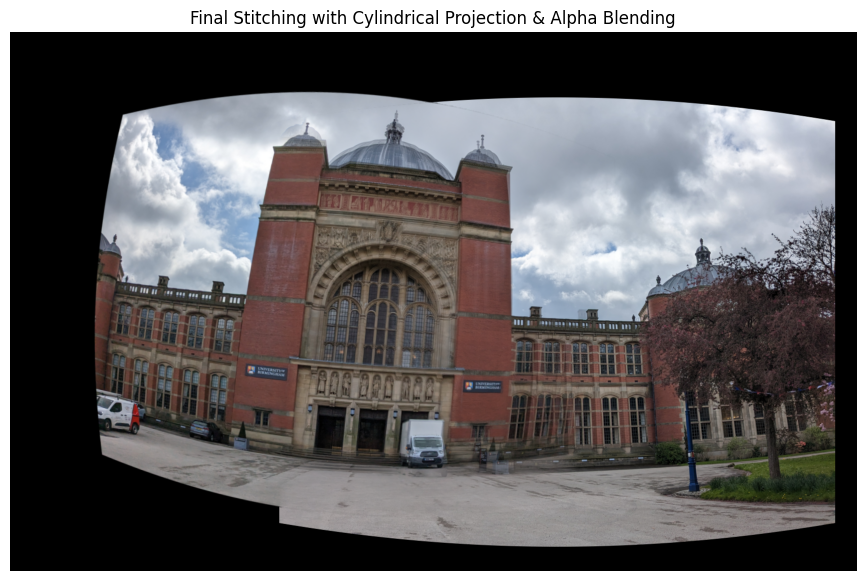

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定义柱面投影核心函数 ---
def cylindrical_projection(img, focal_length):
    """
    将平面图像投影到柱面坐标系上
    """
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    
    # 创建图像的坐标网格
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    # 计算柱面坐标系下的角度和高度
    theta = (x - cx) / focal_length
    h_cyl = (y - cy) / focal_length
    
    # 逆向映射：计算平面坐标系中对应的像素位置
    X_flat = focal_length * np.tan(theta) + cx
    Y_flat = focal_length * h_cyl / np.cos(theta) + cy
    
    # 转换为 float32 格式供 cv2.remap 使用
    map_x = X_flat.astype(np.float32)
    map_y = Y_flat.astype(np.float32)
    
    # 执行重映射 (超出边界的像素填成黑色)
    warped_img = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    return warped_img


# --- 2. 读取与预处理 ---
img1 = cv2.imread('UOB1.jpg') 
img2 = cv2.imread('UOB2.jpg')

if img1 is None or img2 is None:
    raise ValueError("找不到图片，请检查路径！")

# 缩小图像 (30%)
scale_percent = 30 
width1 = int(img1.shape[1] * scale_percent / 100)
height1 = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width1, height1), interpolation=cv2.INTER_AREA)

width2 = int(img2.shape[1] * scale_percent / 100)
height2 = int(img2.shape[0] * scale_percent / 100)
img2 = cv2.resize(img2, (width2, height2), interpolation=cv2.INTER_AREA)

# 【核心新增：执行柱面投影！】
# 估算焦距：这里我们假设焦距等于图像宽度，你可以在报告里讨论如果改变这个值会发生什么
focal_length_estimate = width1 
cyl_img1 = cylindrical_projection(img1, focal_length_estimate)
cyl_img2 = cylindrical_projection(img2, focal_length_estimate)

# 转换颜色空间 (注意：后续所有操作都基于投影后的 cyl_img)
img1_rgb = cv2.cvtColor(cyl_img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(cyl_img2, cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(cyl_img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(cyl_img2, cv2.COLOR_BGR2GRAY)


# --- 3. 提取特征、匹配、计算变换矩阵 ---
sift = cv2.SIFT_create(nfeatures=2000) 
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

if len(good_matches) > 4:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # --- 4. 计算边界框并平移拼接 ---
    h1, w1 = cyl_img1.shape[:2]
    h2, w2 = cyl_img2.shape[:2]

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    warped_corners_img1 = cv2.perspectiveTransform(corners_img1, H)

    all_corners = np.concatenate((warped_corners_img1, corners_img2), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    t_x = -x_min if x_min < 0 else 0
    t_y = -y_min if y_min < 0 else 0

    T = np.array([[1, 0, t_x],
                  [0, 1, t_y],
                  [0, 0, 1]], dtype=np.float32)

    canvas_width = x_max - x_min
    canvas_height = y_max - y_min

    H_translation = T.dot(H)
    
    result = cv2.warpPerspective(img1_rgb, H_translation, (canvas_width, canvas_height))
    result_img2 = cv2.warpPerspective(img2_rgb, T, (canvas_width, canvas_height))
    
#融合
    
    # 【进阶新增逻辑：生成基于距离的 Alpha 融合掩膜】
    
    # 1. 准备两张同样大小的独立画布
    warped_img1 = cv2.warpPerspective(img1_rgb, H_translation, (canvas_width, canvas_height))
    warped_img2 = cv2.warpPerspective(img2_rgb, T, (canvas_width, canvas_height))

    # 2. 生成二值化掩膜 (找出哪些地方有图像，哪些地方是黑边)
    mask1 = (cv2.cvtColor(warped_img1, cv2.COLOR_RGB2GRAY) > 0).astype(np.uint8)
    mask2 = (cv2.cvtColor(warped_img2, cv2.COLOR_RGB2GRAY) > 0).astype(np.uint8)

    # 3. 计算距离变换 (Distance Transform) -> 越靠近图像中心，值越大
    dist1 = cv2.distanceTransform(mask1, cv2.DIST_L2, 3)
    dist2 = cv2.distanceTransform(mask2, cv2.DIST_L2, 3)

    # 4. 计算权重 (Alpha 值) -> 加上 1e-6 是为了防止分母为 0 报错
    weight1 = dist1 / (dist1 + dist2 + 1e-6)
    weight2 = dist2 / (dist1 + dist2 + 1e-6)

    # 5. 将单通道的权重扩展为 3 通道 (为了能和 RGB 图像相乘)
    weight1 = cv2.merge([weight1, weight1, weight1])
    weight2 = cv2.merge([weight2, weight2, weight2])

    # 6. 执行加权融合！
    blended_result = warped_img1 * weight1 + warped_img2 * weight2
    blended_result = blended_result.astype(np.uint8)

    # 显示最终成果
    plt.figure(figsize=(15, 7))
    plt.imshow(blended_result)
    plt.title("Final Stitching with Cylindrical Projection & Alpha Blending")
    plt.axis('off')
    plt.show()

else:
    print("No sufficient matching points were found.")


In [6]:
import numpy as np
import cv2

# 前提：这段代码需要在 cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0) 之后运行
# mask 是 findHomography 返回的掩码，标记了哪些点是内点(Inliers)，哪些是异常值(Outliers)

# 1. 只提取 RANSAC 确认的内点 (Inliers)
inlier_src_pts = src_pts[mask.ravel() == 1]
inlier_dst_pts = dst_pts[mask.ravel() == 1]

# 2. 用计算出的 H 矩阵，将图 1 的内点“投影”到图 2 的坐标系中
# 注意：cv2.perspectiveTransform 需要的数组形状是 (N, 1, 2)
projected_src_pts = cv2.perspectiveTransform(inlier_src_pts, H)

# 3. 计算投影点和实际图 2 匹配点之间的欧氏距离 (Euclidean Distance)
# .squeeze() 用于去掉多余的维度，方便直接相减
errors = np.linalg.norm(projected_src_pts.squeeze() - inlier_dst_pts.squeeze(), axis=1)

# 4. 计算平均误差和最大误差
mean_error = np.mean(errors)
max_error = np.max(errors)
rmse_error = np.sqrt(np.mean(errors**2)) # 均方根误差 (RMSE) 也是常用的指标

print(f"The number of internal points involved in the calculation: {len(inlier_src_pts)}")
print(f"Average re-projection error (Mean Error): {mean_error:.4f} pixels")
print(f"Maximum re-projection error (Max Error): {max_error:.4f} pixels")
print(f"Root Mean Square Error(RMSE): {rmse_error:.4f} pixels")

The number of internal points involved in the calculation: 202
Average re-projection error (Mean Error): 2.1452 pixels
Maximum re-projection error (Max Error): 5.0510 pixels
Root Mean Square Error(RMSE): 2.4137 pixels
